In [1]:
import pandas as pd
df_amazon = pd.read_csv('../data/amazon_books_reviews/Books_rating.csv')
df_7k = pd.read_csv('../data/7k_books/books.csv')

## check columns

In [2]:
print(df_amazon.columns)
print(df_7k.columns)

Index(['Id', 'Title', 'Price', 'User_id', 'profileName', 'review/helpfulness',
       'review/score', 'review/time', 'review/summary', 'review/text'],
      dtype='object')
Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count'],
      dtype='object')


## aggregate and merge

In [4]:
# Aggregate each dataset to one row per book key before merging

def aggregate_for_merge(df, key_col, metrics, prefix, keep_cols=None):
    keep_cols = keep_cols or []

    # Build one aggregation map so key + numeric stats + metadata columns are reduced together.
    agg_map = dict(metrics)
    for col in keep_cols:
        if col not in agg_map:
            agg_map[col] = 'first'

    out = df.groupby(key_col, as_index=False).agg(agg_map)

    # Flatten multi-level columns created by agg.
    flat_cols = []
    keep_cols_set = set(keep_cols)
    for c in out.columns:
        if isinstance(c, tuple):
            base, stat = c
            if stat == '':
                flat_cols.append(base)
            elif stat == 'first' and base in keep_cols_set:
                flat_cols.append(base)
            else:
                flat_cols.append(f"{prefix}_{base}_{stat}")
        else:
            flat_cols.append(c)
    out.columns = flat_cols
    return out

amazon_agg = aggregate_for_merge(
    df_amazon,
    key_col='Id',
    metrics={'review/score': ['mean', 'count']},
    prefix='rating_amazon',
    keep_cols=['Title', 'User_id']
)

books7k_agg = aggregate_for_merge(
    df_7k,
    key_col='isbn10',
    metrics={'average_rating': ['mean']},
    prefix='rating_7k',
    keep_cols=['title', 'authors', 'categories']
)

merged_agg = pd.merge(
    amazon_agg,
    books7k_agg,
    left_on='Id',
    right_on='isbn10',
    how='inner'
)

In [5]:
amazon_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221998 entries, 0 to 221997
Data columns (total 5 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Id                                221998 non-null  object 
 1   rating_amazon_review/score_mean   221998 non-null  float64
 2   rating_amazon_review/score_count  221998 non-null  int64  
 3   Title                             221989 non-null  object 
 4   User_id                           216023 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.5+ MB


In [6]:
books7k_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   isbn10                         6810 non-null   object 
 1   rating_7k_average_rating_mean  6767 non-null   float64
 2   title                          6810 non-null   object 
 3   authors                        6738 non-null   object 
 4   categories                     6711 non-null   object 
dtypes: float64(1), object(4)
memory usage: 266.1+ KB


In [7]:
merged_agg.head()

,Id,rating_amazon_review/score_mean,rating_amazon_review/score_count,Title,User_id,isbn10,rating_7k_average_rating_mean,title,authors,categories
0,0023513209,4.000000,4,Hegel: Reason in History,A1WMH7UL2X6KSE,0023513209,3.64,Reason in History,Georg Wilhelm Friedrich Hegel,Philosophy
1,0029131693,4.000000,2,Tyranny of the Majority : Fundamental Fairness...,A3M6PFX5RKY8B0,0029131693,3.82,Tyranny of the Majority,Lani Guinier,History
2,0029221307,4.666667,3,Origins of the Civil Rights Movements,A11USQSFVTF7Z7,0029221307,4.04,The Origins of the Civil Rights Movement,Aldon D. Morris,History
3,0060001534,4.714286,49,Diary of a Spider,A1BTKAEXPIBKYZ,0060001534,4.25,Diary of a Spider,Doreen Cronin,Juvenile Fiction
4,0060005696,4.042169,166,The Paradox of Choice: Why More Is Less,A3VEB51LRARM41,0060005696,3.84,The Paradox of Choice,Barry Schwartz,Business & Economics


In [8]:
merged_agg.describe()

,rating_amazon_review/score_mean,rating_amazon_review/score_count,rating_7k_average_rating_mean
count,459.000000,459.000000,459.000000
mean,4.243510,38.368192,3.951438
std,0.533221,65.051420,0.279901
min,2.000000,1.000000,3.000000
25%,4.000000,6.000000,3.780000
50%,4.325581,17.000000,3.980000
75%,4.600000,39.000000,4.150000
max,5.000000,602.000000,4.620000


## Is it possible to use collaborative filtering?

In [9]:
reviews_per_user = df_amazon.groupby('User_id').size()
reviews_per_user.describe()

count    1.008972e+06
mean     2.416532e+00
std      1.213263e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      5.795000e+03
dtype: float64

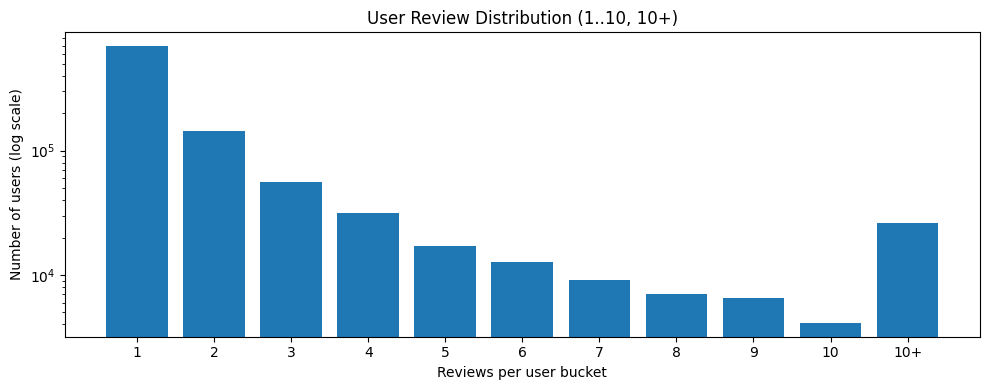

In [10]:
import matplotlib.pyplot as plt

# Count how many users wrote exactly N reviews.
review_count_freq = reviews_per_user.value_counts()

# Build buckets: 1..10 and 10+ (strictly greater than 10).
labels = [str(i) for i in range(1, 11)] + ['10+']
values = [int(review_count_freq.get(i, 0)) for i in range(1, 11)]
values.append(int(review_count_freq[review_count_freq.index > 10].sum()))

plt.figure(figsize=(10, 4))
plt.bar(labels, values)
plt.yscale('log')
plt.xlabel('Reviews per user bucket')
plt.ylabel('Number of users (log scale)')
plt.title('User Review Distribution (1..10, 10+)')
plt.tight_layout()
plt.show()

In [11]:
reviews_per_book = df_amazon.groupby('Id').size()
reviews_per_book.describe()

count    221998.000000
mean         13.513635
std          76.174268
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max        6796.000000
dtype: float64

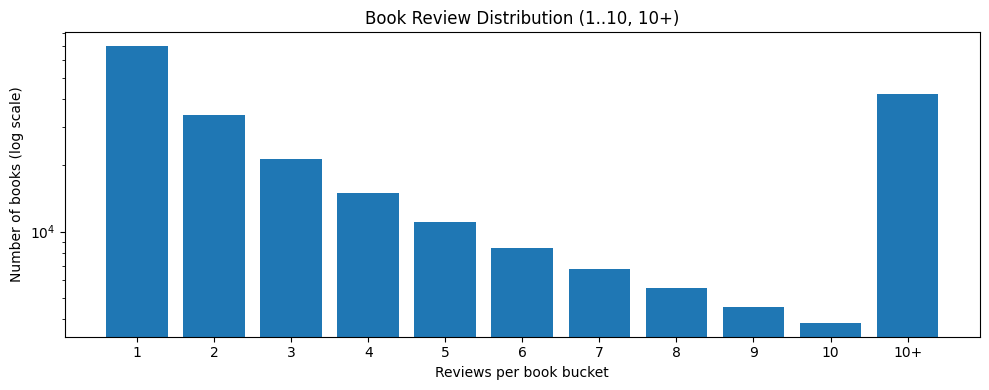

In [12]:
# Count how many books have exactly N reviews.
book_review_count_freq = reviews_per_book.value_counts()

# Build buckets: 1..10 and 10+ (strictly greater than 10).
labels = [str(i) for i in range(1, 11)] + ['10+']
values = [int(book_review_count_freq.get(i, 0)) for i in range(1, 11)]
values.append(int(book_review_count_freq[book_review_count_freq.index > 10].sum()))

plt.figure(figsize=(10, 4))
plt.bar(labels, values)
plt.yscale('log')
plt.xlabel('Reviews per book bucket')
plt.ylabel('Number of books (log scale)')
plt.title('Book Review Distribution (1..10, 10+)')
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

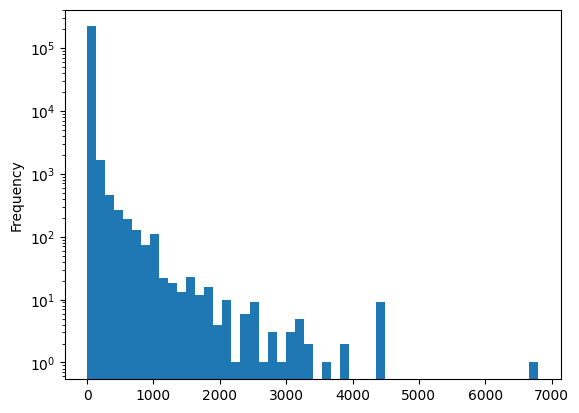

In [13]:
reviews_per_book.plot(kind='hist', bins=50, logy=True)